<a href="https://colab.research.google.com/github/AmanuelDaget/GBPUSD-Foreign-Exchange-Price-Pridiction-Using-LSTM-GRU-BiLSTM/blob/main/GBPUSD_Price_pridiction_Using_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GBPUSD Price pridiction Using LSTM GRU**

**Environment Setup & Installations**

In [49]:
pip install yfinance seaborn plotly

**Import Libraries**

In [91]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, GRU,
    Bidirectional, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


**CONFIGURATION**

In [51]:
DATA_PATH     = 'data/gbpusd_hourly_newyorkTimezone.csv'
MODELS_DIR    = 'models'
PLOTS_DIR     = 'plots'

LOOKBACK      = 72
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
BATCH_SIZE    = 64
EPOCHS        = 100
PATIENCE      = 10
UNITS         = 128
DROPOUT       = 0.3
LEARNING_RATE = 0.001

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

COLORS = {
    'RNN':    '#E24B4A',
    'LSTM':   '#F4B400',
    'GRU':    '#1D9E75',
    'BiLSTM': '#BA7517',
}


print('Configuration loaded.')

Configuration loaded.


**Load the data**

In [52]:
def load_csv_robust(path):
    raw = pd.read_csv(path, header=None, dtype=str)
    data_start_row = None
    for i, val in enumerate(raw.iloc[:, 0]):
        v = str(val).strip()
        try:
            pd.to_datetime(v)
            if v.lower() not in {'price', 'ticker', 'datetime', 'date', ''}:
                data_start_row = i
                break
        except:
            continue
    if data_start_row is None:
        raise ValueError('No datetime rows found.')
    ohlc_keywords = {'open', 'high', 'low', 'close'}
    col_names = None
    for i in range(data_start_row - 1, -1, -1):
        row_vals = [str(v).strip().lower() for v in raw.iloc[i].tolist()]
        if ohlc_keywords.issubset(set(row_vals)):
            col_names = [str(v).strip() for v in raw.iloc[i].tolist()]
            break
    if col_names is None:
        col_names = ['Datetime', 'Open', 'High', 'Low', 'Close']
    df_data = raw.iloc[data_start_row:].copy().reset_index(drop=True)
    df_data.columns = range(df_data.shape[1])
    df_data = df_data.set_index(0)
    df_data.index = pd.to_datetime(df_data.index, utc=True, errors='coerce')
    df_data.index.name = 'Datetime'
    df_data = df_data[df_data.index.notna()]
    df_data.columns = col_names[1:][:df_data.shape[1]]
    df_data = df_data.apply(pd.to_numeric, errors='coerce')
    return df_data

df_raw = load_csv_robust(DATA_PATH)
print(f'Raw shape: {df_raw.shape}  |  {df_raw.index[0]} → {df_raw.index[-1]}')


Raw shape: (14199, 5)  |  2024-01-29 00:00:00+00:00 → 2026-05-15 18:00:00+00:00


# **DATA PREPROCESSING**

In [53]:
df = df_raw.copy()

**Keep only OHLC columns**

In [54]:
required = ["Open", "High", "Low", "Close"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. "
                     f"Available: {list(df.columns)}")
df = df[required].copy()
print(f"  [2.2] Kept columns : {required}")

  [2.2] Kept columns : ['Open', 'High', 'Low', 'Close']


**Convert index to New York timezone**

In [55]:
# The loader already parsed the index as UTC-aware (utc=True).
# We just convert to New York local time — pandas handles EDT/EST DST.
df.index = df.index.tz_convert("America/New_York")
df.sort_index(inplace=True)
df.index.name = "Datetime"
print(f"  [2.3] Timezone     : {df.index.tz}")
print(f"        Date range   : {df.index[0]}  →  {df.index[-1]}")
print(f"        Total rows   : {len(df):,}")

  [2.3] Timezone     : America/New_York
        Date range   : 2024-01-28 19:00:00-05:00  →  2026-05-15 14:00:00-04:00
        Total rows   : 14,199


**Remove duplicate timestamps**

In [56]:
n_before = len(df)
df = df[~df.index.duplicated(keep="first")]
n_dupes = n_before - len(df)
print(f"  [2.4] Duplicate timestamps removed : {n_dupes}")

  [2.4] Duplicate timestamps removed : 0


**Detect & report missing values BEFORE filling**

In [57]:
print(f"\n  [2.5] Missing value report (before treatment):")
for col in df.columns:
    n_nan = df[col].isna().sum()
    pct   = n_nan / len(df) * 100
    print(f"        {col:<8} → {n_nan:>4} NaN  ({pct:.2f}%)")


  [2.5] Missing value report (before treatment):
        Open     →    0 NaN  (0.00%)
        High     →    0 NaN  (0.00%)
        Low      →    0 NaN  (0.00%)
        Close    →    0 NaN  (0.00%)


Detect & fill missing hourly gaps in the time index

In [58]:
full_idx   = pd.date_range(start=df.index.min(),
                            end=df.index.max(),
                            freq="1h",
                            tz=df.index.tz)
missing_ts = full_idx.difference(df.index)
# Classify missing timestamps as weekend (expected) vs weekday (data gap)
weekend_missing  = [t for t in missing_ts if t.weekday() >= 5]
weekday_missing  = [t for t in missing_ts if t.weekday() <  5]

print(f"\n  [2.7] Missing hourly timestamps:")
print(f"        Weekend gaps  (expected) : {len(weekend_missing):>5}")
print(f"        Weekday gaps (data issue): {len(weekday_missing):>5}")

if weekday_missing:
    # Reindex to full hourly frequency, fill new rows by forward-fill
    df = df.reindex(full_idx)
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    # Drop weekend rows (no trading — do NOT feed zero-movement hours to model)
    df = df[df.index.weekday < 5]
    print(f"        Weekday gaps filled via ffill. Weekend rows excluded.")
else:
    # No weekday gaps — just drop weekend rows
    df = df[df.index.weekday < 5]
    print(f"        No weekday gaps found. Weekend rows excluded.")

print(f"        Rows after gap handling  : {len(df):,}")


  [2.7] Missing hourly timestamps:
        Weekend gaps  (expected) :  5132
        Weekday gaps (data issue):   776
        Weekday gaps filled via ffill. Weekend rows excluded.
        Rows after gap handling  : 14,391


**Outlier detection & capping (IQR method per column)**

In [59]:
print(f"\n  [2.8] Outlier capping (IQR × 3.0):")
for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 3.0 * IQR
    hi  = Q3 + 3.0 * IQR
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f"        {col:<8} → {n_outliers:>3} outliers capped  "
          f"[{lo:.5f}, {hi:.5f}]")


  [2.8] Outlier capping (IQR × 3.0):
        Open     →   0 outliers capped  [0.82734, 1.41722]
        High     →   0 outliers capped  [0.82758, 1.41799]
        Low      →   0 outliers capped  [0.82643, 1.41707]
        Close    →   0 outliers capped  [0.82714, 1.41749]


**Sanity checks**

In [60]:
invalid_hl    = (df["High"] < df["Low"]).sum()
invalid_close = ((df["Close"] < df["Low"]) | (df["Close"] > df["High"])).sum()
print(f"\n  [2.9] Sanity checks:")
print(f"        High < Low  violations : {invalid_hl}")
print(f"        Close out of HL range  : {invalid_close}")

# Fix High < Low by swapping (rare but possible in raw data)
if invalid_hl > 0:
    mask = df["High"] < df["Low"]
    df.loc[mask, ["High", "Low"]] = df.loc[mask, ["Low", "High"]].values
    print(f"        Swapped {invalid_hl} High/Low pairs.")


  [2.9] Sanity checks:
        High < Low  violations : 0
        Close out of HL range  : 0


**Stationarity check (Augmented Dickey-Fuller test on Close)**

In [61]:
from statsmodels.tsa.stattools import adfuller

print(f"\n  [2.10] Stationarity — ADF test on Close price:")
adf_result = adfuller(df["Close"].dropna(), autolag="AIC")
print(f"         ADF Statistic : {adf_result[0]:.4f}")
print(f"         p-value       : {adf_result[1]:.4f}")
print(f"         Critical vals : {adf_result[4]}")
if adf_result[1] < 0.05:
    print("         Conclusion    : Series is STATIONARY (p < 0.05) ✓")
else:
    print("         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)")
    print("         Note          : Models will learn from normalised returns — OK.")


  [2.10] Stationarity — ADF test on Close price:
         ADF Statistic : -1.1642
         p-value       : 0.6888
         Critical vals : {'1%': np.float64(-3.4308054961632544), '5%': np.float64(-2.8617413089394477), '10%': np.float64(-2.5668771520040696)}
         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)
         Note          : Models will learn from normalised returns — OK.


**Final preprocessing summary**

In [62]:
print(f"\n  {'─'*50}")
print(f"  Preprocessing complete.")
print(f"  Final dataset shape : {df.shape}")
print(f"  Date range          : {df.index[0]}  →  {df.index[-1]}")
print(f"  Remaining NaN       : {df.isna().sum().sum()}")
print(f"  {'─'*50}")
print(f"\n  Descriptive statistics:")
print(df.describe().round(6).to_string())


  ──────────────────────────────────────────────────
  Preprocessing complete.
  Final dataset shape : (14391, 4)
  Date range          : 2024-01-29 00:00:00-05:00  →  2026-05-15 14:00:00-04:00
  Remaining NaN       : 0
  ──────────────────────────────────────────────────

  Descriptive statistics:
               Open          High           Low         Close
count  14391.000000  14391.000000  14391.000000  14391.000000
mean       1.117274      1.117847      1.116716      1.117280
std        0.047534      0.047549      0.047518      0.047533
min        1.019680      1.020408      1.018226      1.019576
25%        1.080147      1.080614      1.079564      1.080147
50%        1.112347      1.112842      1.111852      1.112347
75%        1.164415      1.164958      1.163941      1.164483
max        1.205400      1.208459      1.202790      1.204674


**Check Wheather Data Normaly distributed or Not**

  Column          Shapiro p    D'Agostino p   Skewness   Kurtosis    Normal?
  ------------------------------------------------------------------------
  Close          1.2606e-46      0.0000e+00    -0.1147    -1.3775       NO ✗
  Open           1.3814e-46      0.0000e+00    -0.1144    -1.3772       NO ✗
  High           1.0979e-46      0.0000e+00    -0.1141    -1.3812       NO ✗
  Low            1.5388e-46      0.0000e+00    -0.1151    -1.3741       NO ✗
  Returns        6.8091e-58      0.0000e+00     0.0687    17.9834       NO ✗


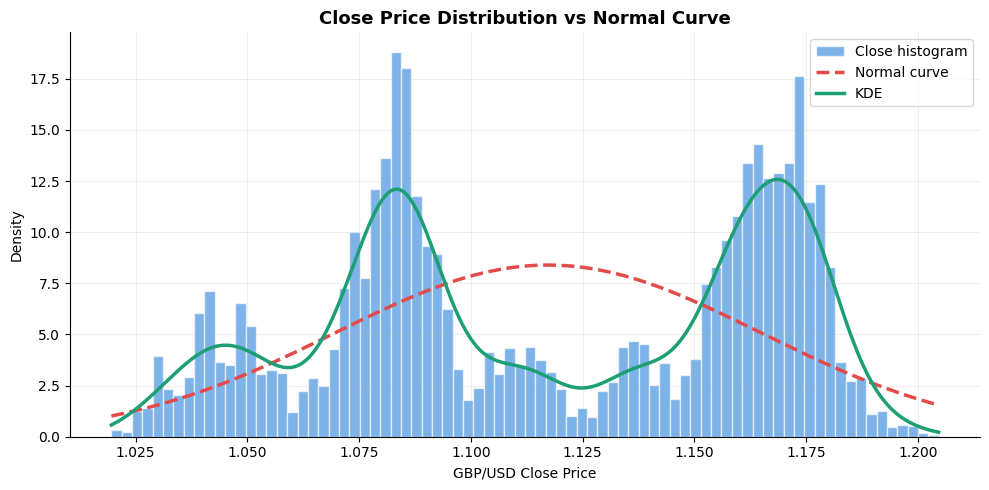

  [Fig 1] Saved → plots/01_close_distribution.png


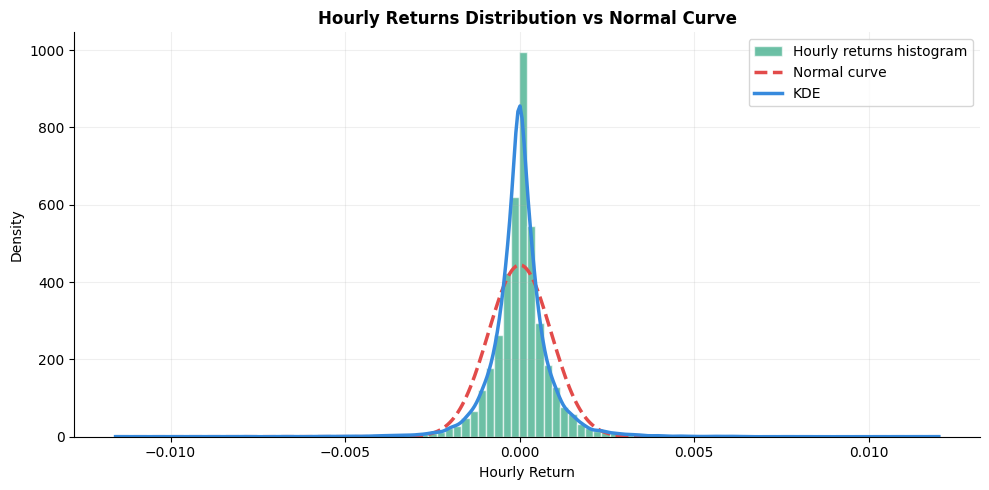

  [Fig 2] Saved → plots/02_returns_distribution.png


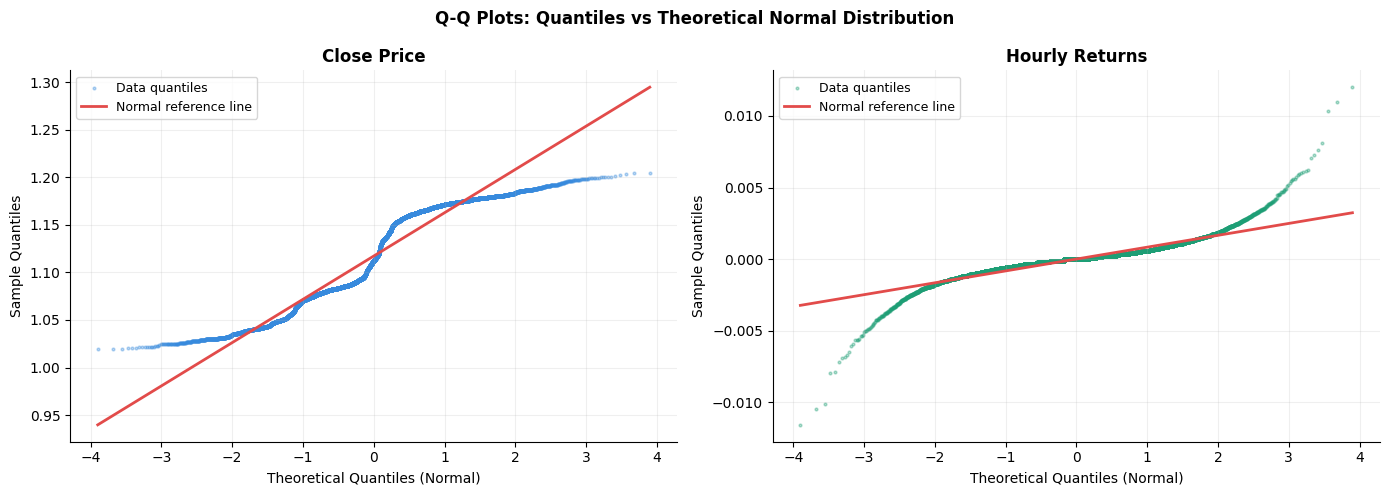

  [Fig 3] Saved → plots/03_qq_plots.png


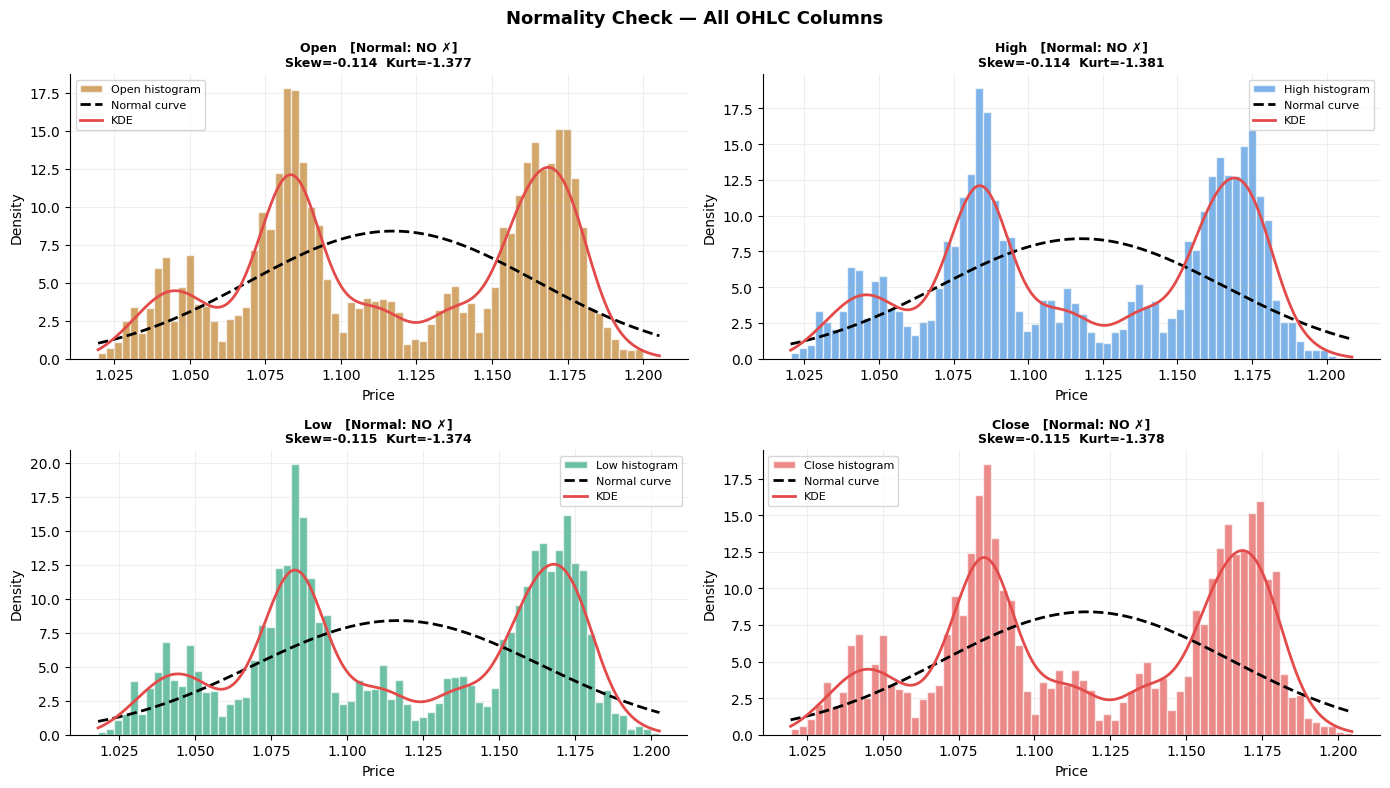

  [Fig 4] Saved → plots/04_ohlc_distributions.png


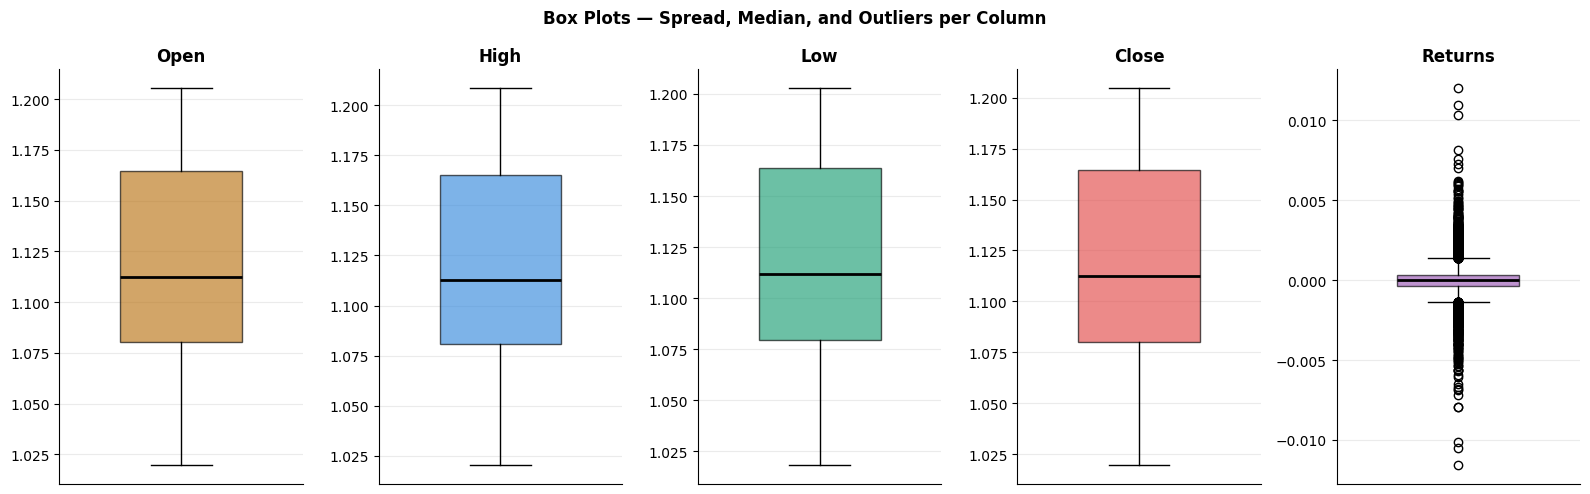

  [Fig 5] Saved → plots/05_boxplots.png

NORMALITY SUMMARY
  Column       Normal?      Skewness   Kurtosis
  ---------------------------------------------
  Close        NO ✗          -0.1147    -1.3775
  Open         NO ✗          -0.1144    -1.3772
  High         NO ✗          -0.1141    -1.3812
  Low          NO ✗          -0.1151    -1.3741
  Returns      NO ✗           0.0687    17.9834


In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

# Setup
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Calculate returns
returns = df["Close"].pct_change().dropna()
test_targets = {
    "Close": df["Close"].values,
    "Open": df["Open"].values,
    "High": df["High"].values,
    "Low": df["Low"].values,
    "Returns": returns.values
}

SAMPLE_SIZE = 5000
normality_results = {}

# Print header
print(f"  {'Column':<12} {'Shapiro p':>12} {'D\'Agostino p':>15} {'Skewness':>10} {'Kurtosis':>10} {'Normal?':>10}")
print("  " + "-" * 72)

# Normality tests
for col, arr in test_targets.items():
    arr = arr[~np.isnan(arr)]
    sample = arr if len(arr) <= SAMPLE_SIZE else np.random.default_rng(42).choice(arr, SAMPLE_SIZE, replace=False)
    sw_p = stats.shapiro(sample)[1]
    da_p = stats.normaltest(arr)[1]
    skew, kurt = float(stats.skew(arr)), float(stats.kurtosis(arr))
    is_normal = (sw_p >= 0.05) and (da_p >= 0.05)
    normality_results[col] = {"Shapiro p": sw_p, "DAgostino p": da_p, "Skewness": skew, "Kurtosis": kurt, "Normal": is_normal}
    print(f"  {col:<12} {sw_p:>12.4e} {da_p:>15.4e} {skew:>10.4f} {kurt:>10.4f} {'YES' if is_normal else 'NO ✗':>10}")

# FIGURE 1: Close Price Distribution
fig, ax = plt.subplots(figsize=(10, 5))
close_vals = df["Close"].values
ax.hist(close_vals, bins=80, color="#378ADD", alpha=0.65, edgecolor="white", density=True, label="Close histogram")
mu, sigma = close_vals.mean(), close_vals.std()
x_range = np.linspace(close_vals.min(), close_vals.max(), 300)
ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), color="#E24B4A", lw=2.5, linestyle="--", label="Normal curve")
ax.plot(x_range, stats.gaussian_kde(close_vals)(x_range), color="#1D9E75", lw=2.5, label="KDE")
ax.set_title("Close Price Distribution vs Normal Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("GBP/USD Close Price")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "01_close_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 1] Saved → {os.path.join(PLOTS_DIR, '01_close_distribution.png')}")

# FIGURE 2: Returns Distribution
fig, ax = plt.subplots(figsize=(10, 5))
ret_vals = returns.values
ax.hist(ret_vals, bins=100, color="#1D9E75", alpha=0.65, edgecolor="white", density=True, label="Hourly returns histogram")
mu_r, sigma_r = ret_vals.mean(), ret_vals.std()
x_r = np.linspace(ret_vals.min(), ret_vals.max(), 400)
ax.plot(x_r, stats.norm.pdf(x_r, mu_r, sigma_r), color="#E24B4A", lw=2.5, linestyle="--", label=f"Normal curve")
ax.plot(x_r, stats.gaussian_kde(ret_vals)(x_r), color="#378ADD", lw=2.5, label="KDE")
ax.set_title("Hourly Returns Distribution vs Normal Curve", fontsize=12, fontweight="bold")
ax.set_xlabel("Hourly Return")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "02_returns_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 2] Saved → {os.path.join(PLOTS_DIR, '02_returns_distribution.png')}")

# FIGURE 3: Q-Q Plots
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q-Q Plots: Quantiles vs Theoretical Normal Distribution", fontsize=12, fontweight="bold")

for ax, arr, title, color in [
    (ax_l, close_vals, "Close Price", "#378ADD"),
    (ax_r, ret_vals, "Hourly Returns", "#1D9E75"),
]:
    osm, osr = stats.probplot(arr, dist="norm")[0]
    slope, intercept, _ = stats.probplot(arr, dist="norm")[1]
    ax.scatter(osm, osr, s=4, alpha=0.35, color=color, label="Data quantiles")
    line_x = np.array([osm.min(), osm.max()])
    ax.plot(line_x, slope * line_x + intercept, color="#E24B4A", lw=2, label="Normal reference line")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Theoretical Quantiles (Normal)")
    ax.set_ylabel("Sample Quantiles")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "03_qq_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 3] Saved → {os.path.join(PLOTS_DIR, '03_qq_plots.png')}")

# FIGURE 4: OHLC Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Normality Check — All OHLC Columns", fontsize=13, fontweight="bold")
axes = axes.flatten()

plot_cols = ["Open", "High", "Low", "Close"]
col_colors = ["#BA7517", "#378ADD", "#1D9E75", "#E24B4A"]

for ax, col, c in zip(axes, plot_cols, col_colors):
    arr = df[col].values
    ax.hist(arr, bins=70, color=c, alpha=0.65, edgecolor="white", density=True, label=f"{col} histogram")
    mu_, s_ = arr.mean(), arr.std()
    xr = np.linspace(arr.min(), arr.max(), 300)
    ax.plot(xr, stats.norm.pdf(xr, mu_, s_), color="black", lw=2, linestyle="--", label="Normal curve")
    ax.plot(xr, stats.gaussian_kde(arr)(xr), color="#E24B4A", lw=2, label="KDE")
    r = normality_results[col]
    verdict = "Normal: NO ✗" if not r["Normal"] else "Normal: YES"
    ax.set_title(f"{col}   [{verdict}]\nSkew={r['Skewness']:.3f}  Kurt={r['Kurtosis']:.3f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Price")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "04_ohlc_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 4] Saved → {os.path.join(PLOTS_DIR, '04_ohlc_distributions.png')}")

# FIGURE 5: Box Plots
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle("Box Plots — Spread, Median, and Outliers per Column", fontsize=12, fontweight="bold")

bp_data = [df["Open"].values, df["High"].values, df["Low"].values, df["Close"].values, returns.values]
bp_labels = ["Open", "High", "Low", "Close", "Returns"]
bp_colors = ["#BA7517", "#378ADD", "#1D9E75", "#E24B4A", "#9B59B6"]

for ax, data, label, c in zip(axes, bp_data, bp_labels, bp_colors):
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, medianprops=dict(color="black", lw=2))
    bp["boxes"][0].set_facecolor(c)
    bp["boxes"][0].set_alpha(0.65)
    ax.set_title(label, fontweight="bold")
    ax.set_xticks([])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "05_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 5] Saved → {os.path.join(PLOTS_DIR, '05_boxplots.png')}")

# Print summary
print("\n" + "=" * 70)
print("NORMALITY SUMMARY")
print("=" * 70)
print(f"  {'Column':<12} {'Normal?':<10} {'Skewness':>10} {'Kurtosis':>10}")
print("  " + "-" * 45)
for col, r in normality_results.items():
    print(f"  {col:<12} {'YES' if r['Normal'] else 'NO ✗':<10} {r['Skewness']:>10.4f} {r['Kurtosis']:>10.4f}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

# Setup
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Calculate returns
returns = df["Close"].pct_change().dropna()
test_targets = {
    "Close": df["Close"].values,
    "Open": df["Open"].values,
    "High": df["High"].values,
    "Low": df["Low"].values,
    "Returns": returns.values
}

SAMPLE_SIZE = 5000
normality_results = {}

# Print header
print(f"  {'Column':<12} {'Shapiro p':>12} {'D\'Agostino p':>15} {'Skewness':>10} {'Kurtosis':>10} {'Normal?':>10}")
print("  " + "-" * 72)

# Normality tests
for col, arr in test_targets.items():
    arr = arr[~np.isnan(arr)]
    sample = arr if len(arr) <= SAMPLE_SIZE else np.random.default_rng(42).choice(arr, SAMPLE_SIZE, replace=False)
    sw_p = stats.shapiro(sample)[1]
    da_p = stats.normaltest(arr)[1]
    skew, kurt = float(stats.skew(arr)), float(stats.kurtosis(arr))
    is_normal = (sw_p >= 0.05) and (da_p >= 0.05)
    normality_results[col] = {"Shapiro p": sw_p, "DAgostino p": da_p, "Skewness": skew, "Kurtosis": kurt, "Normal": is_normal}
    print(f"  {col:<12} {sw_p:>12.4e} {da_p:>15.4e} {skew:>10.4f} {kurt:>10.4f} {'YES' if is_normal else 'NO ✗':>10}")

# FIGURE 1: Close Price Distribution
fig, ax = plt.subplots(figsize=(10, 5))
close_vals = df["Close"].values
ax.hist(close_vals, bins=80, color="#378ADD", alpha=0.65, edgecolor="white", density=True, label="Close histogram")
mu, sigma = close_vals.mean(), close_vals.std()
x_range = np.linspace(close_vals.min(), close_vals.max(), 300)
ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), color="#E24B4A", lw=2.5, linestyle="--", label="Normal curve")
ax.plot(x_range, stats.gaussian_kde(close_vals)(x_range), color="#1D9E75", lw=2.5, label="KDE")
ax.set_title("Close Price Distribution vs Normal Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("GBP/USD Close Price")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "01_close_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 1] Saved → {os.path.join(PLOTS_DIR, '01_close_distribution.png')}")

# FIGURE 2: Returns Distribution
fig, ax = plt.subplots(figsize=(10, 5))
ret_vals = returns.values
ax.hist(ret_vals, bins=100, color="#1D9E75", alpha=0.65, edgecolor="white", density=True, label="Hourly returns histogram")
mu_r, sigma_r = ret_vals.mean(), ret_vals.std()
x_r = np.linspace(ret_vals.min(), ret_vals.max(), 400)
ax.plot(x_r, stats.norm.pdf(x_r, mu_r, sigma_r), color="#E24B4A", lw=2.5, linestyle="--", label=f"Normal curve")
ax.plot(x_r, stats.gaussian_kde(ret_vals)(x_r), color="#378ADD", lw=2.5, label="KDE")
ax.set_title("Hourly Returns Distribution vs Normal Curve", fontsize=12, fontweight="bold")
ax.set_xlabel("Hourly Return")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "02_returns_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 2] Saved → {os.path.join(PLOTS_DIR, '02_returns_distribution.png')}")

# FIGURE 3: Q-Q Plots
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q-Q Plots: Quantiles vs Theoretical Normal Distribution", fontsize=12, fontweight="bold")

for ax, arr, title, color in [
    (ax_l, close_vals, "Close Price", "#378ADD"),
    (ax_r, ret_vals, "Hourly Returns", "#1D9E75"),
]:
    osm, osr = stats.probplot(arr, dist="norm")[0]
    slope, intercept, _ = stats.probplot(arr, dist="norm")[1]
    ax.scatter(osm, osr, s=4, alpha=0.35, color=color, label="Data quantiles")
    line_x = np.array([osm.min(), osm.max()])
    ax.plot(line_x, slope * line_x + intercept, color="#E24B4A", lw=2, label="Normal reference line")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Theoretical Quantiles (Normal)")
    ax.set_ylabel("Sample Quantiles")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "03_qq_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 3] Saved → {os.path.join(PLOTS_DIR, '03_qq_plots.png')}")

# FIGURE 4: OHLC Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Normality Check — All OHLC Columns", fontsize=13, fontweight="bold")
axes = axes.flatten()

plot_cols = ["Open", "High", "Low", "Close"]
col_colors = ["#BA7517", "#378ADD", "#1D9E75", "#E24B4A"]

for ax, col, c in zip(axes, plot_cols, col_colors):
    arr = df[col].values
    ax.hist(arr, bins=70, color=c, alpha=0.65, edgecolor="white", density=True, label=f"{col} histogram")
    mu_, s_ = arr.mean(), arr.std()
    xr = np.linspace(arr.min(), arr.max(), 300)
    ax.plot(xr, stats.norm.pdf(xr, mu_, s_), color="black", lw=2, linestyle="--", label="Normal curve")
    ax.plot(xr, stats.gaussian_kde(arr)(xr), color="#E24B4A", lw=2, label="KDE")
    r = normality_results[col]
    verdict = "Normal: NO ✗" if not r["Normal"] else "Normal: YES"
    ax.set_title(f"{col}   [{verdict}]\nSkew={r['Skewness']:.3f}  Kurt={r['Kurtosis']:.3f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Price")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "04_ohlc_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 4] Saved → {os.path.join(PLOTS_DIR, '04_ohlc_distributions.png')}")

# FIGURE 5: Box Plots
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle("Box Plots — Spread, Median, and Outliers per Column", fontsize=12, fontweight="bold")

bp_data = [df["Open"].values, df["High"].values, df["Low"].values, df["Close"].values, returns.values]
bp_labels = ["Open", "High", "Low", "Close", "Returns"]
bp_colors = ["#BA7517", "#378ADD", "#1D9E75", "#E24B4A", "#9B59B6"]

for ax, data, label, c in zip(axes, bp_data, bp_labels, bp_colors):
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, medianprops=dict(color="black", lw=2))
    bp["boxes"][0].set_facecolor(c)
    bp["boxes"][0].set_alpha(0.65)
    ax.set_title(label, fontweight="bold")
    ax.set_xticks([])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "05_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 5] Saved → {os.path.join(PLOTS_DIR, '05_boxplots.png')}")

# Print summary
print("\n" + "=" * 70)
print("NORMALITY SUMMARY")
print("=" * 70)
print(f"  {'Column':<12} {'Normal?':<10} {'Skewness':>10} {'Kurtosis':>10}")
print("  " + "-" * 45)
for col, r in normality_results.items():
    print(f"  {col:<12} {'YES' if r['Normal'] else 'NO ✗':<10} {r['Skewness']:>10.4f} {r['Kurtosis']:>10.4f}")

**EXPLORATORY DATA ANALYSIS PLOT**


[STEP 3]  Plotting raw data overview ...


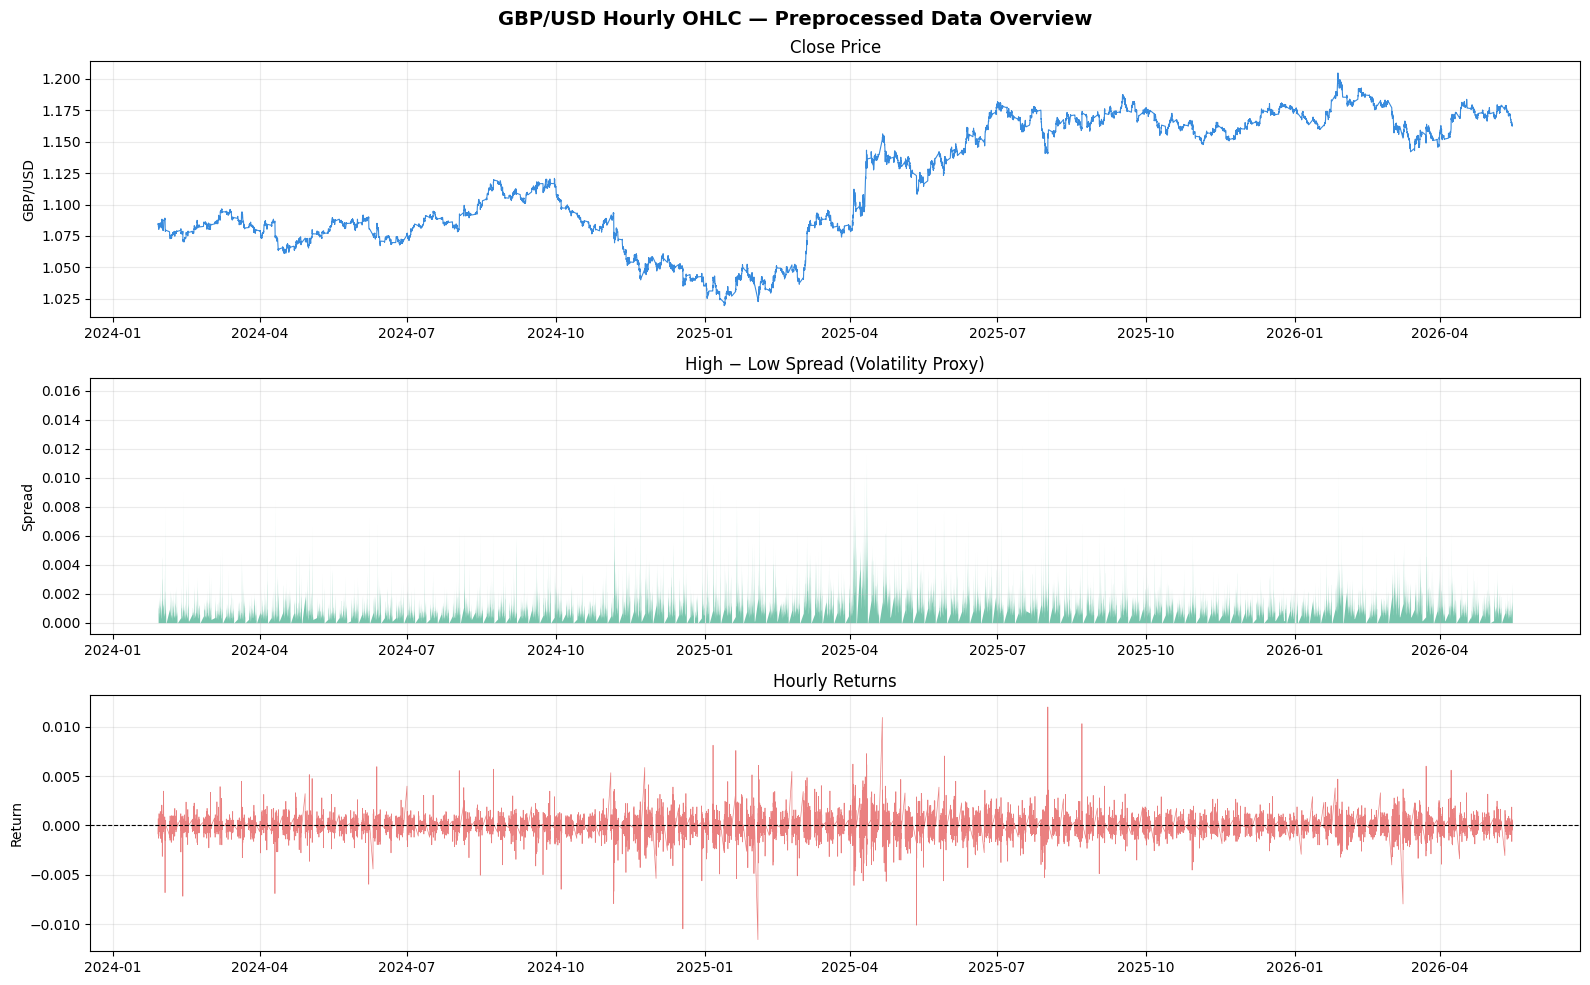

  Saved  →  plots/00_data_overview.png


In [63]:
import os

print("\n[STEP 3]  Plotting raw data overview ...")

os.makedirs(PLOTS_DIR, exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle("GBP/USD Hourly OHLC — Preprocessed Data Overview",
             fontsize=14, fontweight="bold")

# Close price
axes[0].plot(df.index, df["Close"], color="#378ADD", linewidth=0.8)
axes[0].set_title("Close Price")
axes[0].set_ylabel("GBP/USD")
axes[0].grid(True, alpha=0.25)

# High - Low spread
axes[1].fill_between(df.index,
                     df["High"] - df["Low"],
                     color="#1D9E75", alpha=0.6, linewidth=0)
axes[1].set_title("High − Low Spread (Volatility Proxy)")
axes[1].set_ylabel("Spread")
axes[1].grid(True, alpha=0.25)

# Hourly returns
ret = df["Close"].pct_change().dropna()
axes[2].plot(df.index[1:], ret, color="#E24B4A", linewidth=0.5, alpha=0.7)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Hourly Returns")
axes[2].set_ylabel("Return")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "00_data_overview.png")
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"  Saved  →  {path}")

**Feature engineering**

In [64]:
print("\n" + "=" * 70)
print("  FEATURE ENGINEERING  (upgraded for Direction Accuracy)")
print("=" * 70)

fe = df.copy()

# ── Original features ────────────────────────────────────────────────────────
fe["returns"]    = fe["Close"].pct_change()
fe["hl_spread"]  = fe["High"] - fe["Low"]
fe["oc_spread"]  = fe["Close"] - fe["Open"]
fe["sma_10"]     = fe["Close"].rolling(10).mean()
fe["sma_24"]     = fe["Close"].rolling(24).mean()
fe["ema_12"]     = fe["Close"].ewm(span=12, adjust=False).mean()
fe["momentum"]   = fe["Close"] - fe["Close"].shift(4)
fe["volatility"] = fe["returns"].rolling(12).std()

# ── New: RSI-14  (overbought/oversold — strong directional signal) ───────────
delta   = fe["Close"].diff()
gain    = delta.clip(lower=0).rolling(14).mean()
loss    = (-delta.clip(upper=0)).rolling(14).mean()
rs      = gain / (loss + 1e-9)
fe["rsi_14"] = 100 - (100 / (1 + rs))

# ── New: Bollinger Band position  (Close relative to upper/lower bands) ──────
bb_mid        = fe["Close"].rolling(20).mean()
bb_std        = fe["Close"].rolling(20).std()
fe["bb_pos"]  = (fe["Close"] - bb_mid) / (2 * bb_std + 1e-9)  # -1..+1

# ── New: Lagged returns (t-1, t-2, t-3)  — direct direction memory ───────────
fe["ret_lag1"] = fe["returns"].shift(1)
fe["ret_lag2"] = fe["returns"].shift(2)
fe["ret_lag3"] = fe["returns"].shift(3)

# ── New: Price vs SMA ratio  (trend strength signal) ─────────────────────────
fe["price_sma_ratio"] = fe["Close"] / (fe["sma_24"] + 1e-9) - 1.0

fe.dropna(inplace=True)

FEATURES = [
    # Price candle
    "Open", "High", "Low", "Close",
    # Return & spread
    "returns", "hl_spread", "oc_spread",
    # Trend
    "sma_10", "sma_24", "ema_12",
    # Momentum
    "momentum", "volatility",
    # Direction-specific (NEW)
    "rsi_14", "bb_pos",
    "ret_lag1", "ret_lag2", "ret_lag3",
    "price_sma_ratio",
]

CLOSE_IDX = FEATURES.index("Close")

print(f"  Total features : {len(FEATURES)}")
for i, f in enumerate(FEATURES):
    tag = "  [NEW]" if f in ("rsi_14", "bb_pos", "ret_lag1", "ret_lag2",
                              "ret_lag3", "price_sma_ratio") else ""
    print(f"    [{i:>2}] {f}{tag}")
print(f"  Rows : {len(fe):,}")


  FEATURE ENGINEERING  (upgraded for Direction Accuracy)
  Total features : 18
    [ 0] Open
    [ 1] High
    [ 2] Low
    [ 3] Close
    [ 4] returns
    [ 5] hl_spread
    [ 6] oc_spread
    [ 7] sma_10
    [ 8] sma_24
    [ 9] ema_12
    [10] momentum
    [11] volatility
    [12] rsi_14  [NEW]
    [13] bb_pos  [NEW]
    [14] ret_lag1  [NEW]
    [15] ret_lag2  [NEW]
    [16] ret_lag3  [NEW]
    [17] price_sma_ratio  [NEW]
  Rows : 14,368


**Normalize features**

In [65]:
print("\n" + "=" * 70)
print("  NORMALISATION")
print("=" * 70)

# First determine split indices from raw array length
n_total = len(fe)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

# Fit scaler ONLY on training rows — never let val/test data influence scaling
scaler = MinMaxScaler(feature_range=(0, 1))
train_raw = fe[FEATURES].values[:n_train]
scaler.fit(train_raw)

scaled = scaler.transform(fe[FEATURES].values)

print(f"  Scaler fitted on training rows only  ({n_train:,} rows)")
print(f"  Scaled array  : {scaled.shape}")
print(f"  Min / Max     : {scaled.min():.4f} / {scaled.max():.4f}")


  NORMALISATION
  Scaler fitted on training rows only  (10,057 rows)
  Scaled array  : (14368, 18)
  Min / Max     : 0.0000 / 1.1555


**SEQUENCE CREATION  (sliding window — lookback = 24 hours)**

In [66]:
print("\n" + "=" * 70)
print(f"  SEQUENCE CREATION  (lookback = {LOOKBACK} hours)")
print("=" * 70)


def create_sequences(data, lookback, target_idx):
    """
    Sliding window: for each step i, X = data[i-lookback:i], y = data[i, target_idx].
    Returns float32 arrays to reduce GPU memory usage.
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback: i])
        y.append(data[i, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X, y = create_sequences(scaled, LOOKBACK, CLOSE_IDX)
print(f"  X : {X.shape}   (samples, timesteps, features)")
print(f"  y : {y.shape}   (samples,)")


  SEQUENCE CREATION  (lookback = 72 hours)
  X : (14296, 72, 18)   (samples, timesteps, features)
  y : (14296,)   (samples,)


**Train / Validation / Test split**

In [67]:
print("\n" + "=" * 70)
print("  TRAIN / VAL / TEST SPLIT  (chronological — no shuffle)")
print("=" * 70)

n       = len(X)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
n_test  = n - n_train - n_val

X_train, y_train = X[:n_train],               y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],  y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],         y[n_train+n_val:]

INPUT_SHAPE = (LOOKBACK, len(FEATURES))

print(f"  Total samples : {n:,}")
print(f"  +------------------+--------+------------+")
print(f"  | Split            | Ratio  |    Samples |")
print(f"  +------------------+--------+------------+")
print(f"  | Train            |  70 %  | {X_train.shape[0]:>10,} |")
print(f"  | Validation       |  15 %  | {X_val.shape[0]:>10,} |")
print(f"  | Test (held-out)  |  15 %  | {X_test.shape[0]:>10,} |")
print(f"  +------------------+--------+------------+")
print(f"  Input shape per sample : {INPUT_SHAPE}")


  TRAIN / VAL / TEST SPLIT  (chronological — no shuffle)
  Total samples : 14,296
  +------------------+--------+------------+
  | Split            | Ratio  |    Samples |
  +------------------+--------+------------+
  | Train            |  70 %  |     10,007 |
  | Validation       |  15 %  |      2,144 |
  | Test (held-out)  |  15 %  |      2,145 |
  +------------------+--------+------------+
  Input shape per sample : (72, 18)


# **MODEL**

**MODEL ARCHITECTURE DEFINITIONS**

In [68]:
print("\n" + "=" * 70)
print("  MODEL ARCHITECTURE DEFINITIONS")
print("=" * 70)

# ── Direction-Accuracy weighted loss ─────────────────────────────────────────
# Standard MSE minimises price error but ignores direction.
# This combined loss adds a penalty when the model predicts the wrong direction.
# alpha controls the trade-off: 0 = pure MSE, 1 = pure direction penalty.
DA_ALPHA = 0.45   # 45% direction penalty weight — tuned for GBP/USD hourly

def da_weighted_loss(alpha=DA_ALPHA):
    """
    Custom loss = (1-alpha)*MSE + alpha*direction_penalty

    direction_penalty = mean( max(0, -(y_true_diff * y_pred_diff)) )
    A positive value means the signs disagreed (wrong direction predicted).
    This nudges the model to care about direction, not just price proximity.
    """
    import tensorflow as tf
    def loss(y_true, y_pred):
        mse  = tf.reduce_mean(tf.square(y_true - y_pred))
        diff_true = y_true[1:] - y_true[:-1]
        diff_pred = y_pred[1:] - y_pred[:-1]
        direction_penalty = tf.reduce_mean(
            tf.maximum(0.0, -(diff_true * diff_pred))
        )
        return (1.0 - alpha) * mse + alpha * direction_penalty
    loss.__name__ = "da_weighted_loss"
    return loss


def build_lstm(input_shape, units, dropout, lr):
    """
    Stacked LSTM with Direction-Accuracy weighted loss.
    LSTM(units) → Dropout → LSTM(units) → Dropout → Dense(32,relu) → Dense(1)
    """
    model = Sequential(name="LSTM")
    model.add(LSTM(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(LSTM(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(lr,clipnorm=1.0),
        loss=da_weighted_loss(DA_ALPHA),
        metrics=["mae"]
    )
    return model


def build_gru(input_shape, units, dropout, lr):
    """
    Stacked GRU with Direction-Accuracy weighted loss.
    GRU(units) → Dropout → GRU(units) → Dropout → Dense(32,relu) → Dense(1)
    """
    model = Sequential(name="GRU")
    model.add(GRU(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(GRU(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(
         optimizer=Adam(lr,clipnorm=1.0),
        loss=da_weighted_loss(DA_ALPHA),
        metrics=["mae"]
    )
    return model


def build_bilstm(input_shape, units, dropout, lr):
    """
    Bidirectional LSTM with Direction-Accuracy weighted loss.
    BiLSTM(units) → Dropout → BiLSTM(units//2) → Dropout → Dense(32,relu) → Dense(1)
    """
    model = Sequential(name="BiLSTM")
    model.add(Bidirectional(
        LSTM(units, return_sequences=True), input_shape=input_shape
    ))
    model.add(Dropout(dropout))
    model.add(Bidirectional(LSTM(units // 2, return_sequences=False)))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(
         optimizer=Adam(lr,clipnorm=1.0),
        loss=da_weighted_loss(DA_ALPHA),
        metrics=["mae"]
    )
    return model


def build_rnn(input_shape, units, dropout, lr):
    """
    Vanilla SimpleRNN with Direction-Accuracy weighted loss.
    SimpleRNN(units) → Dropout → SimpleRNN(units) → Dropout → Dense(32,relu) → Dense(1)
    """
    model = Sequential(name="Vanilla_RNN")
    model.add(SimpleRNN(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(SimpleRNN(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(lr),
        loss=da_weighted_loss(DA_ALPHA),
        metrics=["mae"]
    )
    return model


print("  Architecture  : 2 recurrent layers + Dropout + Dense(32) + Dense(1)")
print(f"  Loss function : DA-Weighted  (alpha={DA_ALPHA}  =  35% direction penalty)")
print("  Optimizer     : Adam")
print("  Models defined: LSTM | GRU | BiLSTM | Vanilla_RNN")




  MODEL ARCHITECTURE DEFINITIONS
  Architecture  : 2 recurrent layers + Dropout + Dense(32) + Dense(1)
  Loss function : DA-Weighted  (alpha=0.45  =  35% direction penalty)
  Optimizer     : Adam
  Models defined: LSTM | GRU | BiLSTM | Vanilla_RNN


**SHARED HELPER FUNCTIONS**

In [69]:
def inverse_close(scaled_vals):
    """
    Invert MinMaxScaler for the Close column only.
    Builds a full-feature dummy array, sets Close column, inverts, extracts.
    """
    dummy               = np.zeros((len(scaled_vals), len(FEATURES)))
    dummy[:, CLOSE_IDX] = scaled_vals
    return scaler.inverse_transform(dummy)[:, CLOSE_IDX]


def compute_metrics(actual, preds):
    """
    Compute RMSE, MAE, MAPE, and Direction Accuracy (DA).

    DA = % of consecutive-hour moves where the predicted direction
         (up/down) matches the actual direction.  Random baseline = 50%.
    """
    rmse = float(np.sqrt(mean_squared_error(actual, preds)))
    nrmse = float(rmse / (actual.max() - actual.min() + 1e-9) * 100)
    mae  = float(mean_absolute_error(actual, preds))
    mape = float(np.mean(np.abs((actual - preds) / (actual + 1e-9))) * 100)
    da   = float(
        np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(preds))) * 100
    )

    return {"RMSE": rmse, "NRMSE (%)": nrmse, "MAE": mae,
            "MAPE": mape, "DA (%)": da}
# ── Palette (professional, consistent across all models) ─────────────────────
_C_ACTUAL  = "#111111"   # near-black  — actual price (always)
_C_TRAIN   = "#2CA02C"   # green       — train predictions / train loss
_C_VAL     = "#FF7F0E"   # orange      — validation predictions / val loss
_C_ZERO    = "#E24B4A"   # red         — zero residual reference line
_C_MEAN    = "#FF7F0E"   # orange      — mean residual line
_ALPHA_L   = 0.92        # main line alpha
_LW_ACTUAL = 1.6         # actual price line width
_LW_PRED   = 1.2         # predicted line width

def run_inference(model, X, y):
    """Run model on any split and return (preds_price, actual_price, metrics)."""
    preds_sc = model.predict(X, verbose=0).flatten()
    preds    = inverse_close(preds_sc)
    actual   = inverse_close(y)
    metrics  = compute_metrics(actual, preds)
    return preds, actual, metrics


def train_model(model, name, X_tr, y_tr, X_v, y_v,
                epochs=EPOCHS, patience=PATIENCE, batch=BATCH_SIZE):
    """
    Train one model with three callbacks:
      EarlyStopping      — stops when val_loss stagnates for `patience` epochs;
                           restores best weights automatically.
      ReduceLROnPlateau  — halves LR after 5 stagnant epochs (floor 1e-6).
      ModelCheckpoint    — saves best weights to disk.
    Returns (history, elapsed_seconds).
    """
    ckpt = os.path.join(MODELS_DIR, f"{name}_best.weights.h5")
    cbs  = [
        EarlyStopping(
            monitor="val_loss", patience=patience,
            restore_best_weights=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=5, min_lr=1e-6, verbose=0
        ),
        ModelCheckpoint(
            ckpt, monitor="val_loss",
            save_best_only=True, save_weights_only=True, verbose=0
        ),
    ]
    t0 = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs, batch_size=batch,
        callbacks=cbs, verbose=1,
    )
    elapsed = time.time() - t0
    best_ep  = int(np.argmin(history.history["val_loss"])) + 1
    best_val = float(min(history.history["val_loss"]))
    print(f"\n  Training done  |  Best epoch: {best_ep}  |  "
          f"Best val_loss: {best_val:.6f}  |  Time: {elapsed:.1f}s")
    return history, elapsed


def print_validation_report(name, val_preds, val_actual, val_metrics):
    DA_THRESHOLD = 50.0
    da_ok  = val_metrics["DA (%)"] >= DA_THRESHOLD
    status = "OK  (>= 50%)" if da_ok else "LOW  (< 50% — worse than random!)"
    div = "=" * 62

    print(f"\n  +{div}+")
    print(f"  |{'VALIDATION SET REPORT — ' + name:^62}|")
    print(f"  +{div}+")
    print(f"  |  RMSE               : {val_metrics['RMSE']:>10.6f}{'':>29}|")
    print(f"  |  NRMSE (%)          : {val_metrics['NRMSE (%)']:>9.4f} %{'':>29}|")
    print(f"  |  MAE                : {val_metrics['MAE']:>10.6f}{'':>29}|")
    print(f"  |  MAPE               : {val_metrics['MAPE']:>9.4f} %{'':>29}|")
    print(f"  |  Direction Acc (DA) : {val_metrics['DA (%)']:>9.2f} %   {status:<22}|")
    print(f"  +{div}+")

    if not da_ok:
        print(f"\n  [!] DA WARNING: {val_metrics['DA (%)']:.2f}% is below the 50% random baseline.")
        print(f"  [!] Adjustments already applied in this run:")
        print(f"        - DA-weighted loss (alpha={DA_ALPHA}) penalises wrong directions")
        print(f"        - 6 new direction-signal features (RSI, BB, lagged returns)")
        print(f"        - Scaler fitted on training only (no data leakage)")
        print(f"  [!] If DA is STILL low, consider:")
        print(f"        - Increasing DA_ALPHA toward 0.50")
        print(f"        - Increasing LOOKBACK (e.g. 96 hours)")
        print(f"        - Increasing UNITS (e.g. 256)")
    return da_ok


def _style_ax(ax, title, xlabel="Hours", ylabel="GBP/USD Price",
              fontsize=10, title_color="black"):
    ax.set_title(title, fontsize=fontsize, fontweight="bold", color=title_color)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.20, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_individual_results(name, history,
                             train_preds, train_actual,
                             val_preds,   val_actual,
                             test_preds,  test_actual,
                             test_metrics, color):
    """
    Produces 6 separate, publication-quality figures for one model.

    Figure 1 — Loss curve        (train=green, val=orange)
    Figure 2 — Train predictions (last 500 h)
    Figure 3 — Validation predictions
    Figure 4 — Test predictions  (full)
    Figure 5 — Test predictions  (first 300 h zoom)
    Figure 6 — Scatter + residual histogram (test)

    color  : model accent color from COLORS dict (used for predicted line)
    """
    h   = history.history
    eps = list(range(1, len(h["loss"]) + 1))
    m   = test_metrics
    tr_m  = compute_metrics(train_actual, train_preds)
    val_m = compute_metrics(val_actual,   val_preds)
    da_color = "darkgreen" if val_m["DA (%)"] >= 50 else "crimson"
    best_ep  = int(np.argmin(h["val_loss"])) + 1

    # ── Figure 1 : Loss Curve ────────────────────────────────────────────────
    fig1, ax = plt.subplots(figsize=(9, 5))
    ax.plot(eps, h["loss"],     color=_C_TRAIN, lw=2.2,
            label="Train loss",      alpha=_ALPHA_L)
    ax.plot(eps, h["val_loss"], color=_C_VAL,   lw=2.2,
            label="Validation loss", alpha=_ALPHA_L, linestyle="--")
    ax.axvline(best_ep, color="grey", lw=1.2, linestyle=":",
               label=f"Best epoch {best_ep}")
    ax.fill_between(eps, h["loss"], h["val_loss"],
                    alpha=0.07, color=_C_VAL)
    _style_ax(ax,
              f"[{name}]  Training vs Validation Loss",
              xlabel="Epoch", ylabel="DA-Weighted Loss")
    ax.legend(fontsize=10)
    fig1.tight_layout()
    p = os.path.join(PLOTS_DIR, f"{name}_1_loss_curve.png")
    fig1.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  [Fig 1] Saved → {p}")

    # ── Figure 2 : Train Set Predictions ────────────────────────────────────
    show = min(500, len(train_actual))
    fig2, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train_actual[-show:], color=_C_ACTUAL, lw=1.4,
            label="Actual",    alpha=_ALPHA_L)
    ax.plot(train_preds[-show:],  color=_C_TRAIN,  lw=1.1,
            label="Predicted", alpha=0.80)
    _style_ax(ax,
              f"[{name}]  Train Set — last {show} hours\n"
              f"RMSE={tr_m['RMSE']:.5f}  NRMSE={tr_m['NRMSE (%)']:.2f}%"
              f"  DA={tr_m['DA (%)']:.1f}%")
    ax.legend(fontsize=9)
    fig2.tight_layout()
    p = os.path.join(PLOTS_DIR, f"{name}_2_train_preds.png")
    fig2.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  [Fig 2] Saved → {p}")

    # ── Figure 3 : Validation Set Predictions ───────────────────────────────
    fig3, ax = plt.subplots(figsize=(14, 4))
    ax.plot(val_actual, color=_C_ACTUAL, lw=1.4,
            label="Actual",    alpha=_ALPHA_L)
    ax.plot(val_preds,  color=_C_VAL,    lw=1.1,
            label="Predicted", alpha=0.85)
    da_flag = "✓ OK" if val_m["DA (%)"] >= 50 else "✗ LOW"
    _style_ax(ax,
              f"[{name}]  Validation Set\n"
              f"RMSE={val_m['RMSE']:.5f}  NRMSE={val_m['NRMSE (%)']:.2f}%"
              f"  MAE={val_m['MAE']:.5f}  DA={val_m['DA (%)']:.1f}%  [{da_flag}]",
              title_color=da_color)
    ax.legend(fontsize=9)
    fig3.tight_layout()
    p = os.path.join(PLOTS_DIR, f"{name}_3_val_preds.png")
    fig3.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  [Fig 3] Saved → {p}")

    # ── Figure 4 : Test Set Full ─────────────────────────────────────────────
    fig4, ax = plt.subplots(figsize=(14, 4))
    ax.plot(test_actual, color=_C_ACTUAL, lw=1.4,
            label="Actual",    alpha=_ALPHA_L)
    ax.plot(test_preds,  color=color,     lw=1.1,
            label="Predicted", alpha=0.85)
    _style_ax(ax,
              f"[{name}]  Test Set (Full)\n"
              f"RMSE={m['RMSE']:.5f}  NRMSE={m['NRMSE (%)']:.2f}%"
              f"  MAE={m['MAE']:.5f}  MAPE={m['MAPE']:.2f}%  DA={m['DA (%)']:.1f}%")
    ax.legend(fontsize=9)
    fig4.tight_layout()
    p = os.path.join(PLOTS_DIR, f"{name}_4_test_full.png")
    fig4.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  [Fig 4] Saved → {p}")

    # ── Figure 5 : Test Set Zoomed (first 300 h) ─────────────────────────────
    Z = min(300, len(test_actual))
    fig5, ax = plt.subplots(figsize=(14, 4))
    ax.plot(test_actual[:Z], color=_C_ACTUAL, lw=1.5,
            label="Actual",    alpha=_ALPHA_L)
    ax.plot(test_preds[:Z],  color=color,     lw=1.2,
            label="Predicted", alpha=0.85)
    _style_ax(ax, f"[{name}]  Test Set — first {Z} hours (zoom)")
    ax.legend(fontsize=9)
    fig5.tight_layout()
    p = os.path.join(PLOTS_DIR, f"{name}_5_test_zoom.png")
    fig5.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  [Fig 5] Saved → {p}")

    # ── Figure 6 : Scatter + Residual Histogram ──────────────────────────────
    residuals = test_preds - test_actual
    fig6, (ax_s, ax_r) = plt.subplots(1, 2, figsize=(12, 5))

    # Scatter
    ax_s.scatter(test_actual, test_preds, s=5, alpha=0.30, color=color)
    lo = min(test_actual.min(), test_preds.min())
    hi = max(test_actual.max(), test_preds.max())
    ax_s.plot([lo, hi], [lo, hi], color="black", lw=1.2,
              linestyle="--", label="Perfect fit")
    _style_ax(ax_s,
              f"[{name}]  Actual vs Predicted\n"
              f"Residual mean={residuals.mean():.5f}  std={residuals.std():.5f}",
              xlabel="Actual Price", ylabel="Predicted Price")
    ax_s.legend(fontsize=9)

    # Residual histogram
    ax_r.hist(residuals, bins=60, color=color, alpha=0.75, edgecolor="white")
    ax_r.axvline(0, color="black", lw=1.4, linestyle="--", label="Zero residual")
    ax_r.axvline(residuals.mean(), color=_C_VAL, lw=1.4,
                 linestyle="-", label=f"Mean={residuals.mean():.5f}")
    _style_ax(ax_r,
              f"[{name}]  Residual Distribution",
              xlabel="Predicted − Actual", ylabel="Frequency")
    ax_r.legend(fontsize=9)

    fig6.tight_layout()
    p = os.path.join(PLOTS_DIR, f"{name}_6_scatter_residual.png")
    fig6.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  [Fig 6] Saved → {p}")


def print_test_report(name, metrics, params, elapsed):
    da_flag = "GOOD" if metrics["DA (%)"] >= 50 else "CHECK"
    div = "=" * 62
    print(f"\n  +{div}+")
    print(f"  |{'TEST SET REPORT — ' + name:^62}|")
    print(f"  +{div}+")
    print(f"  |  Parameters         : {params:>10,}{'':>29}|")
    print(f"  |  Training time      : {elapsed:>9.1f} s{'':>29}|")
    print(f"  +{div}+")
    print(f"  |  RMSE               : {metrics['RMSE']:>10.6f}{'':>29}|")
    print(f"  |  NRMSE (%)          : {metrics['NRMSE (%)']:>9.4f} %{'':>29}|")
    print(f"  |  MAE                : {metrics['MAE']:>10.6f}{'':>29}|")
    print(f"  |  MAPE               : {metrics['MAPE']:>9.4f} %{'':>29}|")
    da_flag_str = f"GOOD (>= 50%)" if metrics["DA (%)"] >= 50 else "CHECK (< 50%)"
    print(f"  |  Direction Acc (DA) : {metrics['DA (%)']:>9.2f} %   [{da_flag_str}]{'':>15}|")
    print(f"  +{div}+\n")


In [70]:
# RESULTS STORE
results = {}


**MODEL 1 — LSTM**

In [71]:
print("\n  [LSTM]  STEP 1 : BUILD")
print("  " + "-" * 55)
lstm_model = build_lstm(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
lstm_model.summary()
print(f"  Parameters : {lstm_model.count_params():,}")


  [LSTM]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 72, 128)        │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,009 (824.25 KB)

 Trainable params: 211,009 (824.25 KB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 211,009


**LSTM Train**

In [72]:
print("\n  [LSTM]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}  "
      f"epochs={EPOCHS}  patience={PATIENCE}  batch={BATCH_SIZE}\n")
lstm_history, lstm_time = train_model(
    lstm_model, "LSTM", X_train, y_train, X_val, y_val
)


  [LSTM]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=10,007  Val=2,144  epochs=100  patience=10  batch=64

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0055 - mae: 0.0565 - val_loss: 0.0018 - val_mae: 0.0560 - learning_rate: 0.0010
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0010 - mae: 0.0312 - val_loss: 3.2635e-04 - val_mae: 0.0226 - learning_rate: 0.0010
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.3798e-04 - mae: 0.0283 - val_loss: 0.0029 - val_mae: 0.0714 - learning_rate: 0.0010
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.8698e-04 - mae: 0.0256 - val_loss: 0.0025 - val_mae: 0.0666 - learning_rate: 0.0010
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 6.0171e-04 - mae: 0.0238 - val_loss: 1.3082e-04 - val_mae: 0.0131 - learning_rate: 0.0010
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.1567e-04 - mae: 0.0219 - val_loss: 2.9779e-04 - va

**LSTM VALIDATE  ← check metrics here before running t**

In [73]:
print("\n  [LSTM]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
lstm_val_preds, lstm_val_actual, lstm_val_metrics = run_inference(
    lstm_model, X_val, y_val
)
lstm_val_ok = print_validation_report("LSTM", lstm_val_preds,
                                       lstm_val_actual, lstm_val_metrics)


  [LSTM]  STEP 3 : VALIDATE
  -------------------------------------------------------

  +==============================================================+
  |                 VALIDATION SET REPORT — LSTM                 |
  +==============================================================+
  |  RMSE               :   0.000960                             |
  |  NRMSE (%)          :    2.4201 %                             |
  |  MAE                :   0.000697                             |
  |  MAPE               :    0.0597 %                             |
  |  Direction Acc (DA) :     40.74 %   LOW  (< 50% — worse than random!)|
  +==============================================================+

  [!] DA WARNING: 40.74% is below the 50% random baseline.
  [!] Adjustments already applied in this run:
        - DA-weighted loss (alpha=0.45) penalises wrong directions
        - 6 new direction-signal features (RSI, BB, lagged returns)
        - Scaler fitted on training only (no data leakage

**TEST**

In [74]:
print("\n  [LSTM]  STEP 4 : TEST  (held-out test set)")
print("  " + "-" * 55)
print(f"  Running inference on {X_test.shape[0]:,} unseen samples ...")
lstm_train_preds, lstm_train_actual, _ = run_inference(lstm_model, X_train, y_train)
lstm_test_preds,  lstm_test_actual, lstm_test_metrics = run_inference(
    lstm_model, X_test, y_test
)
print_test_report("LSTM", lstm_test_metrics, lstm_model.count_params(), lstm_time)


  [LSTM]  STEP 4 : TEST  (held-out test set)
  -------------------------------------------------------
  Running inference on 2,145 unseen samples ...

  +==============================================================+
  |                    TEST SET REPORT — LSTM                    |
  +==============================================================+
  |  Parameters         :    211,009                             |
  |  Training time      :      88.7 s                             |
  +==============================================================+
  |  RMSE               :   0.001304                             |
  |  NRMSE (%)          :    2.0783 %                             |
  |  MAE                :   0.000901                             |
  |  MAPE               :    0.0769 %                             |
  |  Direction Acc (DA) :     41.88 %   [CHECK (< 50%)]               |
  +==============================================================+



**PLOT**

  [LSTM]  STEP 5 : PLOT
  -------------------------------------------------------


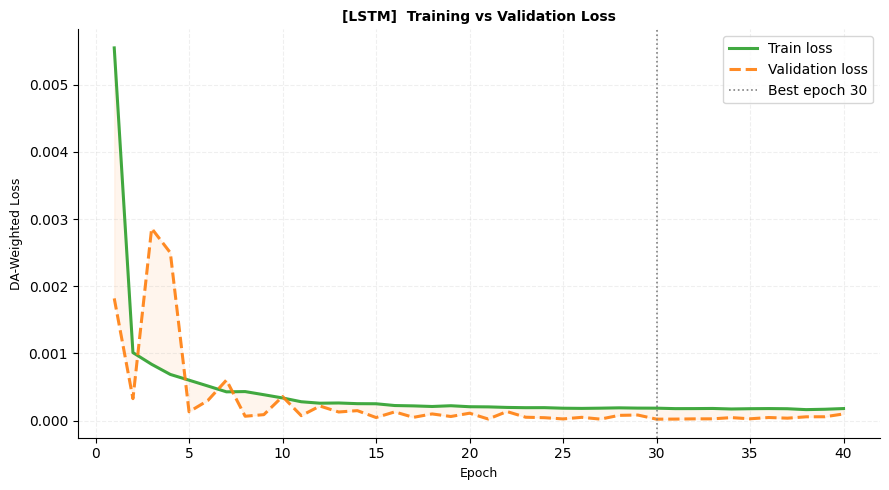

  [Fig 1] Saved → plots/LSTM_1_loss_curve.png


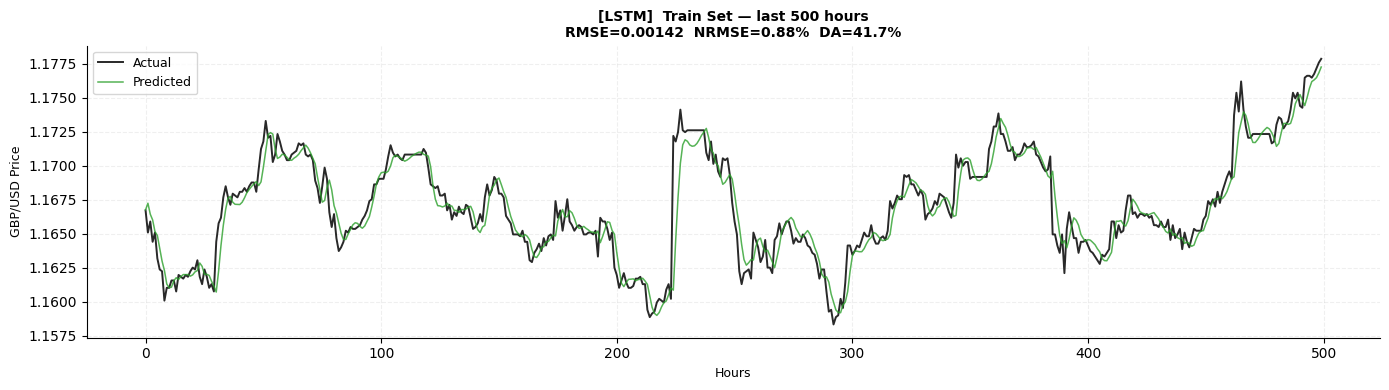

  [Fig 2] Saved → plots/LSTM_2_train_preds.png


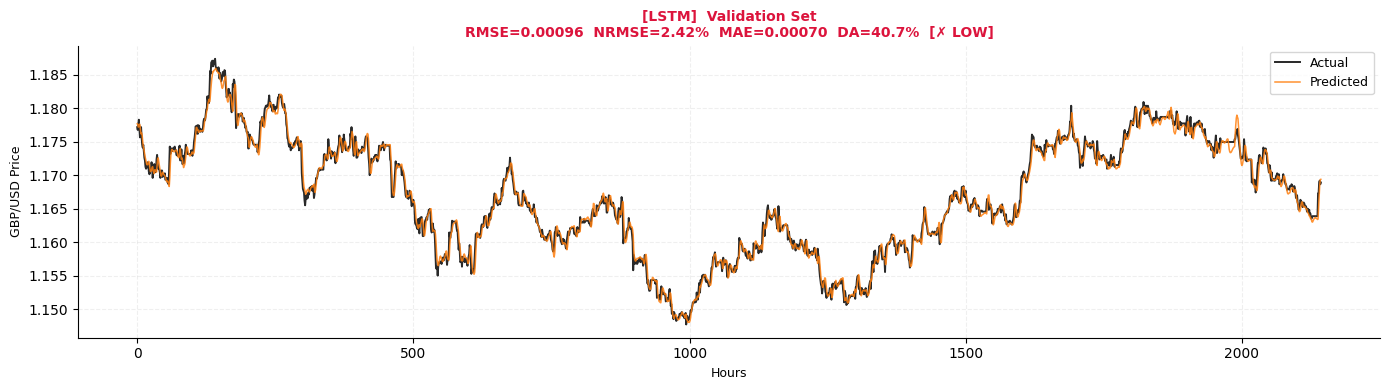

  [Fig 3] Saved → plots/LSTM_3_val_preds.png


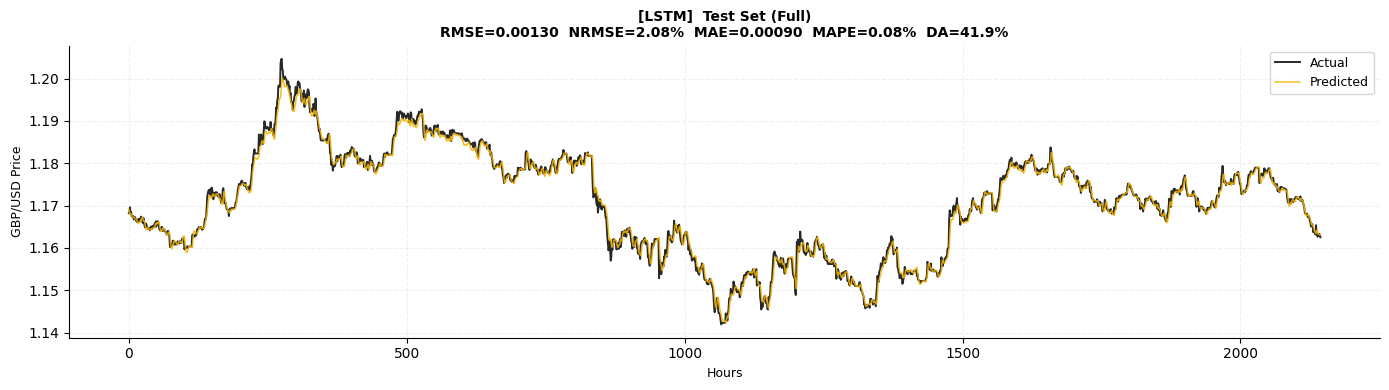

  [Fig 4] Saved → plots/LSTM_4_test_full.png


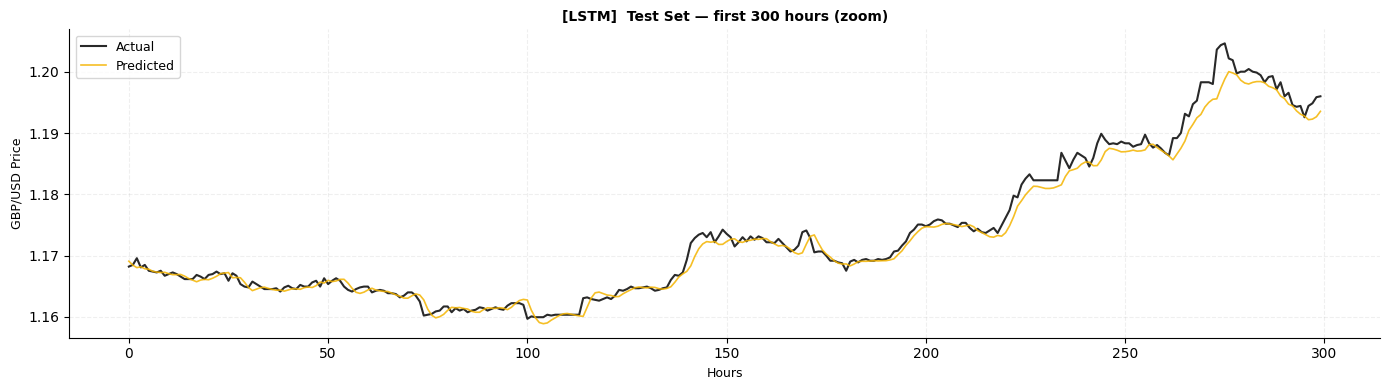

  [Fig 5] Saved → plots/LSTM_5_test_zoom.png


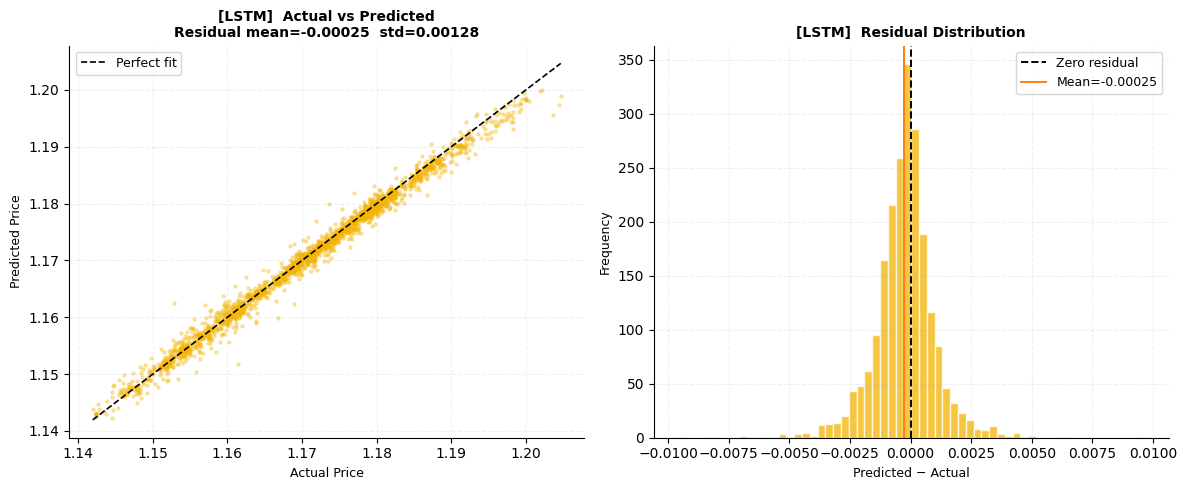

  [Fig 6] Saved → plots/LSTM_6_scatter_residual.png
  LSTM complete.



In [75]:
print("  [LSTM]  STEP 5 : PLOT")
print("  " + "-" * 55)
plot_individual_results(
    "LSTM", lstm_history,
    lstm_train_preds, lstm_train_actual,
    lstm_val_preds,   lstm_val_actual,
    lstm_test_preds,  lstm_test_actual,
    lstm_test_metrics, COLORS["LSTM"]
)

results["LSTM"] = {
    "history":      lstm_history,
    "val_metrics":  lstm_val_metrics,
    "preds":        lstm_test_preds,
    "actual":       lstm_test_actual,
    "metrics":      lstm_test_metrics,
    "params":       lstm_model.count_params(),
    "time":         lstm_time,
}
print("  LSTM complete.\n")

# **GRU**

**BUILD**

In [76]:
print("\n  [GRU]  STEP 1 : BUILD")
print("  " + "-" * 55)
gru_model = build_gru(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
gru_model.summary()
print(f"  Parameters : {gru_model.count_params():,}")


  [GRU]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 72, 128)        │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,065 (625.25 KB)

 Trainable params: 160,065 (625.25 KB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 160,065


**TRAIN**

In [77]:
print("\n  [GRU]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}\n")
gru_history, gru_time = train_model(
    gru_model, "GRU", X_train, y_train, X_val, y_val
)


  [GRU]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=10,007  Val=2,144

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0041 - mae: 0.0532 - val_loss: 0.0026 - val_mae: 0.0684 - learning_rate: 0.0010
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0010 - mae: 0.0319 - val_loss: 0.0014 - val_mae: 0.0496 - learning_rate: 0.0010
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.6451e-04 - mae: 0.0292 - val_loss: 2.2091e-04 - val_mae: 0.0185 - learning_rate: 0.0010
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 6.3329e-04 - mae: 0.0246 - val_loss: 0.0011 - val_mae: 0.0440 - learning_rate: 0.0010
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.1434e-04 - mae: 0.0222 - val_loss: 0.0013 - val_mae: 0.0483 - learning_rate: 0.0010
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.1284e-04 - mae: 0.0221 - val_loss: 1.1627e-04 - val_mae: 0.0129 - learning_rate: 0.0010
Ep

**VALIDATION REPORT**

In [78]:
print("\n  [GRU]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
gru_val_preds, gru_val_actual, gru_val_metrics = run_inference(
    gru_model, X_val, y_val
)
gru_val_ok = print_validation_report("GRU", gru_val_preds,
                                      gru_val_actual, gru_val_metrics)



  [GRU]  STEP 3 : VALIDATE
  -------------------------------------------------------

  +==============================================================+
  |                 VALIDATION SET REPORT — GRU                  |
  +==============================================================+
  |  RMSE               :   0.001167                             |
  |  NRMSE (%)          :    2.9422 %                             |
  |  MAE                :   0.000922                             |
  |  MAPE               :    0.0791 %                             |
  |  Direction Acc (DA) :     40.83 %   LOW  (< 50% — worse than random!)|
  +==============================================================+

  [!] DA WARNING: 40.83% is below the 50% random baseline.
  [!] Adjustments already applied in this run:
        - DA-weighted loss (alpha=0.45) penalises wrong directions
        - 6 new direction-signal features (RSI, BB, lagged returns)
        - Scaler fitted on training only (no data leakage)

**TEST**

In [79]:
# print("\n  [LSTM]  STEP 4 : TEST  (held-out test set)")
# print("  " + "-" * 55)
# print(f"  Running inference on {X_test.shape[0]:,} unseen samples ...")
# lstm_train_preds, lstm_train_actual, _ = run_inference(lstm_model, X_train, y_train)
# lstm_test_preds,  lstm_test_actual, lstm_test_metrics = run_inference(
#     lstm_model, X_test, y_test
# )
# print_test_report("LSTM", lstm_test_metrics, lstm_model.count_params(), lstm_time)

**PLOTS FOR GRU**

In [80]:
# print("  [GRU]  STEP 5 : PLOT")
# print("  " + "-" * 55)
# plot_individual_results(
#     "GRU", gru_history,
#     gru_train_preds, gru_train_actual,
#     gru_val_preds,   gru_val_actual,
#     gru_test_preds,  gru_test_actual,
#     gru_test_metrics, COLORS["GRU"]
# )

# results["GRU"] = {
#     "history": gru_history,
#     "val_metrics":  gru_val_metrics,
#     "preds":   gru_test_preds,
#     "actual":  gru_test_actual,
#     "metrics": gru_test_metrics,
#     "params":  gru_model.count_params(),
#     "time":    gru_time,
# }
# print("  GRU complete.\n")

# **BiLSTM  (Bidirectional LSTM)**

**BUILD**

In [81]:
print("\n  [BiLSTM]  STEP 1 : BUILD")
print("  " + "-" * 55)
bilstm_model = build_bilstm(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
bilstm_model.summary()
print(f"  Parameters : {bilstm_model.count_params():,}")


  [BiLSTM]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 72, 256)        │       150,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 72, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,041 (1.22 MB)

 Trainable params: 319,041 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 319,041


**TRAIN**

In [82]:
print("\n  [BiLSTM]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}\n")
bilstm_history, bilstm_time = train_model(
    bilstm_model, "BiLSTM", X_train, y_train, X_val, y_val
)


  [BiLSTM]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=10,007  Val=2,144

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0042 - mae: 0.0509 - val_loss: 3.3504e-04 - val_mae: 0.0210 - learning_rate: 0.0010
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 9.3535e-04 - mae: 0.0305 - val_loss: 3.2603e-04 - val_mae: 0.0216 - learning_rate: 0.0010
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 8.1222e-04 - mae: 0.0284 - val_loss: 1.8309e-04 - val_mae: 0.0155 - learning_rate: 0.0010
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 6.4756e-04 - mae: 0.0250 - val_loss: 0.0022 - val_mae: 0.0617 - learning_rate: 0.0010
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 5.8059e-04 - mae: 0.0238 - val_loss: 7.7402e-04 - val_mae: 0.0365 - learning_rate: 0.0010
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 5.6472e-04 - mae: 0.0233 - val_loss: 0.0010 - val_mae: 0.0415 - learning_

**VALIDATION REPORT**

In [83]:
print("\n  [BiLSTM]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
bilstm_val_preds, bilstm_val_actual, bilstm_val_metrics = run_inference(
    bilstm_model, X_val, y_val
)
bilstm_val_ok = print_validation_report("BiLSTM", bilstm_val_preds,
                                         bilstm_val_actual, bilstm_val_metrics)


  [BiLSTM]  STEP 3 : VALIDATE
  -------------------------------------------------------

  +==============================================================+
  |                VALIDATION SET REPORT — BiLSTM                |
  +==============================================================+
  |  RMSE               :   0.002431                             |
  |  NRMSE (%)          :    6.1292 %                             |
  |  MAE                :   0.002151                             |
  |  MAPE               :    0.1840 %                             |
  |  Direction Acc (DA) :     40.50 %   LOW  (< 50% — worse than random!)|
  +==============================================================+

  [!] DA WARNING: 40.50% is below the 50% random baseline.
  [!] Adjustments already applied in this run:
        - DA-weighted loss (alpha=0.45) penalises wrong directions
        - 6 new direction-signal features (RSI, BB, lagged returns)
        - Scaler fitted on training only (no data leaka

**TEST**

In [84]:
# print("\n  [BiLSTM]  STEP 4 : TEST")
# print("  " + "-" * 55)
# bilstm_train_preds, bilstm_train_actual, _ = run_inference(bilstm_model, X_train, y_train)
# bilstm_test_preds,  bilstm_test_actual, bilstm_test_metrics = run_inference(
#     bilstm_model, X_test, y_test
# )
# print_test_report("BiLSTM", bilstm_test_metrics, bilstm_model.count_params(), bilstm_time)

**PLOT**

In [85]:
# print("  [BiLSTM]  STEP 5 : PLOT")
# print("  " + "-" * 55)
# plot_individual_results(
#     "BiLSTM", bilstm_history,
#     bilstm_train_preds, bilstm_train_actual,
#     bilstm_val_preds,   bilstm_val_actual,
#     bilstm_test_preds,  bilstm_test_actual,
#     bilstm_test_metrics, COLORS["BiLSTM"]
# )

# results["BiLSTM"] = {
#     "history": bilstm_history,
#     "val_metrics":  bilstm_val_metrics,
#     "preds":   bilstm_test_preds,
#     "actual":  bilstm_test_actual,
#     "metrics": bilstm_test_metrics,
#     "params":  bilstm_model.count_params(),
#     "time":    bilstm_time,
# }
# print("  BiLSTM complete.\n")


# **Vanilla RNN**

**BUILD**

In [86]:
print("\n  [RNN]  STEP 1 : BUILD")
print("  " + "-" * 55)
rnn_model = build_rnn(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
rnn_model.summary()
print(f"  Parameters : {rnn_model.count_params():,}")


  [RNN]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 72, 128)        │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,873 (218.25 KB)

 Trainable params: 55,873 (218.25 KB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 55,873


**TRAIN**

In [87]:
print("\n  [RNN]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}\n")
rnn_history, rnn_time = train_model(
    rnn_model, "Vanilla_RNN", X_train, y_train, X_val, y_val
)


  [RNN]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=10,007  Val=2,144

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 0.0174 - mae: 0.1152 - val_loss: 9.7371e-04 - val_mae: 0.0371 - learning_rate: 0.0010
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0032 - mae: 0.0582 - val_loss: 1.9681e-04 - val_mae: 0.0146 - learning_rate: 0.0010
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0020 - mae: 0.0460 - val_loss: 2.8166e-04 - val_mae: 0.0178 - learning_rate: 0.0010
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0015 - mae: 0.0403 - val_loss: 4.4440e-04 - val_mae: 0.0227 - learning_rate: 0.0010
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0013 - mae: 0.0366 - val_loss: 2.2334e-04 - val_mae: 0.0168 - learning_rate: 0.0010
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0011 - mae: 0.0341 - val_loss: 5.6803e-04 - val_mae: 0.0277 - learning_rate: 0.0010
E

**VALIDATION REPORT**

In [88]:
print("\n  [RNN]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
rnn_val_preds, rnn_val_actual, rnn_val_metrics = run_inference(
    rnn_model, X_val, y_val
)
rnn_val_ok = print_validation_report("Vanilla_RNN", rnn_val_preds,
                                      rnn_val_actual, rnn_val_metrics)


  [RNN]  STEP 3 : VALIDATE
  -------------------------------------------------------

  +==============================================================+
  |             VALIDATION SET REPORT — Vanilla_RNN              |
  +==============================================================+
  |  RMSE               :   0.002207                             |
  |  NRMSE (%)          :    5.5650 %                             |
  |  MAE                :   0.001649                             |
  |  MAPE               :    0.1408 %                             |
  |  Direction Acc (DA) :     41.30 %   LOW  (< 50% — worse than random!)|
  +==============================================================+

  [!] DA WARNING: 41.30% is below the 50% random baseline.
  [!] Adjustments already applied in this run:
        - DA-weighted loss (alpha=0.45) penalises wrong directions
        - 6 new direction-signal features (RSI, BB, lagged returns)
        - Scaler fitted on training only (no data leakage)

**TEST**

In [89]:
# print("\n  [RNN]  STEP 4 : TEST")
# print("  " + "-" * 55)
# rnn_train_preds, rnn_train_actual, _ = run_inference(rnn_model, X_train, y_train)
# rnn_test_preds,  rnn_test_actual, rnn_test_metrics = run_inference(
#     rnn_model, X_test, y_test
# )
# print_test_report("Vanilla_RNN", rnn_test_metrics, rnn_model.count_params(), rnn_time)

**PLOT**

In [90]:
# print("  [RNN]  STEP 5 : PLOT")
# print("  " + "-" * 55)
# plot_individual_results(
#     "Vanilla_RNN", rnn_history,
#     rnn_train_preds, rnn_train_actual,
#     rnn_val_preds,   rnn_val_actual,
#     rnn_test_preds,  rnn_test_actual,
#     rnn_test_metrics, COLORS["Vanilla_RNN"]
# )

# results["Vanilla_RNN"] = {
#     "history": rnn_history,
#     "val_metrics":  rnn_val_metrics,
#     "preds":   rnn_test_preds,
#     "actual":  rnn_test_actual,
#     "metrics": rnn_test_metrics,
#     "params":  rnn_model.count_params(),
#     "time":    rnn_time,
# }
# print("  Vanilla RNN complete.\n")

# **CROSS-MODEL COMPARISON**